In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

PLOTS_DIR = "plots"
if not os.path.exists(PLOTS_DIR):
    os.makedirs(PLOTS_DIR)
RNG = np.random.default_rng(42)  # reproducible random number generator

In [2]:
def save_plot(fig, filename):
    fig_file_path = os.path.join(PLOTS_DIR, filename)
    fig.savefig(fig_file_path, dpi=300)

In [3]:
n = 20
p = 0.35
num_repetitions = 1_000_000

samples = RNG.binomial(1, p, size=(num_repetitions, n))
sample_means = samples.mean(axis=1)

In [4]:
alphas = np.arange(0.5, 1 + 0.05, 0.05) # add step to endpoint to be inclusive
empirical_freq = np.array([np.mean(sample_means >= a) for a in alphas])

In [5]:
plots = {}

def gen_graph(plots=plots):
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.set_title(r"Bernoulli samples mean exceeding $\alpha$")
    ax.set_xlabel(r"$\alpha$")
    ax.set_ylabel(r"$\mathbb{P}(mean(X) \geq \alpha)$")
    ax.grid(alpha=0.3)

    for label, y_values in plots.items():
        ax.plot(alphas, y_values, "-o", label=label)
    ax.legend()
    plt.show()
    return fig

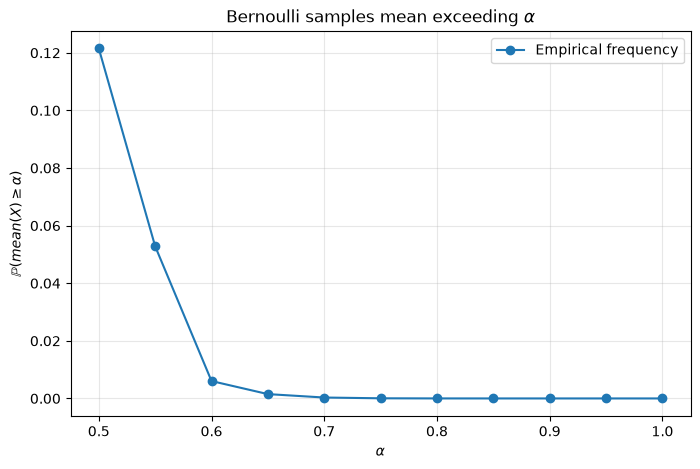

In [6]:
plots["Empirical frequency"] = empirical_freq
fig = gen_graph()
save_plot(fig, "ef.png")

In [7]:
def markov_bound(alphas, expected_value):
    return np.minimum(expected_value / alphas, 1.0)


mean_X = p
markov = markov_bound(alphas, mean_X)

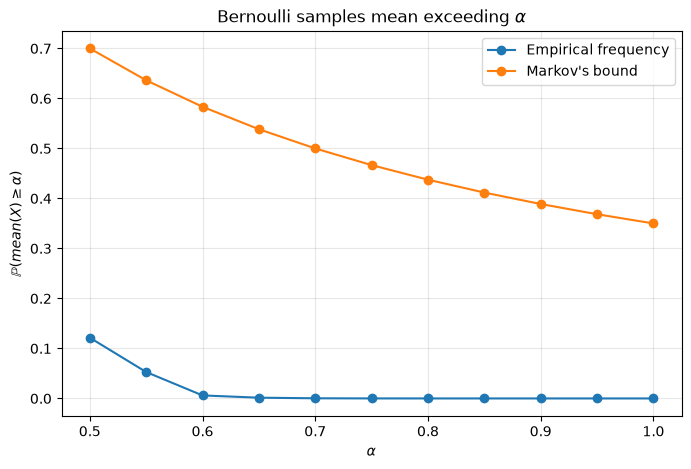

In [8]:
plots["Markov's bound"] = markov
fig = gen_graph()
save_plot(fig, "ef_markov.png")

In [9]:
def chebyshev_bound(alphas, mean, var, n):
    # P(|X - E[X]| >= eps) => we use eps = a - E[X]
    eps = alphas - mean
    bound = np.where(eps > 0, var / (n * np.square(eps)), 1.0)
    return np.minimum(bound, 1.0)


var_X = p * (1 - p)
chebyshev = chebyshev_bound(alphas, mean_X, var_X, n)

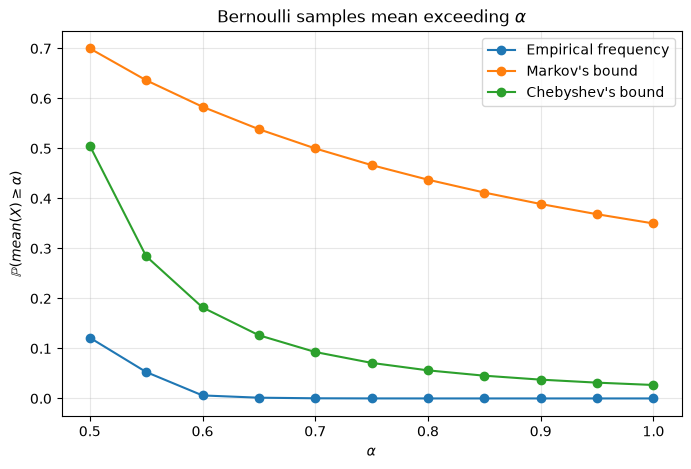

In [10]:
plots["Chebyshev's bound"] = chebyshev
fig = gen_graph()
save_plot(fig, "ef_markov_chebyshev.png")

In [11]:
def hoeffding_bound(alphas, mean, n):
    eps = alphas - mean
    bound = np.where(eps > 0, np.exp(-2 * n * np.square(eps)), 1.0)
    return np.minimum(bound, 1.0)


hoeffding = hoeffding_bound(alphas, mean_X, n)

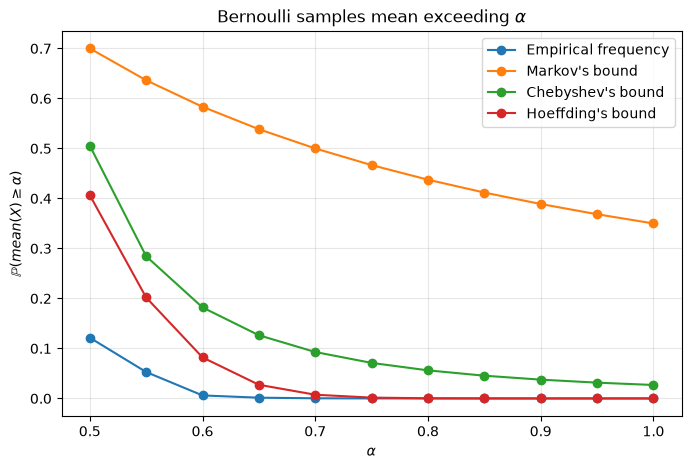

In [12]:
plots["Hoeffding's bound"] = hoeffding
fig = gen_graph()
save_plot(fig, "ef_markov_chebyshev_hoeffding.png")